<a href="https://colab.research.google.com/github/Voidneon/SA2---Implementing-YOLOv26-with-NMS-Free-Detection/blob/main/SA2_Gr16_Gonzales_Bagallon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Group 16
- Gonzales, Dominic Ryan
- Bagallon, Radzie

Annotations later code for now. Attempting to make it work first

In [2]:
import pandas as pd
# Pandas is used as to organize the hyperparameter settings and validation metrics(Precision, Recall, mAP50) into formatted tables.
# it's a foundational tool used in the code base for structured data manipulation and creation of tabular reports.
from google.colab import drive
# from google.colab import drive enables us to have a connection from colab to google drive, which allows us to access the vehicle dataset
# It depends from user to user as they have to connect to their own PERSONAL google drive, the dataset is available in our github
# https://github.com/Voidneon/SA2---Implementing-YOLOv26-with-NMS-Free-Detection
import torch
# torch is a deep learning framework that powers YOLO architecture and provides direct interface tools for the GPU.
# in our usecase, we use it to clear the VRAM cache to ensure the cloud GPU has enough memory to start the next training config.
import gc
# the gc moduele provides an interface to the python garbage collector.
# by calling gc.collect() after each model, we ensure memory from the previous training run is released.
import matplotlib.pyplot as plt
# The primary library used to generate charts and diagnostic images.
# We utilize it here to create a grouped bar chart to visually compare the performance of models 1 to 3 side by side.
import numpy as np
# Numpy is a computing library used for handling large arrays and performing mathematical operations.
# These lines import our libraries/tools to use in our application of the annotated dataset onto several configs of YoloV26 nano
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [3]:
!uv pip install ultralytics
# Command uses the uv package manager to install the ultralytics library
# Installing this enables our book to have access to the YOLOv26 architecture
import ultralytics
# it imports the ultralytics package/library into our notebook
# It allows access to YOLO and other high-level frameworks needed to run diagnostics and manage the model
from ultralytics import YOLO
# this one imports the YOLO class specifically
# it allows us to initialize the yolo26n.pt(yolov26 nano)

Using Python 3.12.12 environment at: /usr
Resolved 53 packages in 408ms
Prepared 2 packages in 55ms
Installed 2 packages in 9ms
 + ultralytics==8.4.21
 + ultralytics-thop==2.0.18
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
ultralytics.checks()
# This runs a diagnostic check of our environment to verify that our CPU,GPU(Tesla T4) and sof  tware dependencies are correctly configured
# It ensures that our Colab session has "Setup complete" so that we dont encounter hardware errors during training.

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.5/112.6 GB disk)


In [5]:
drive.mount('/content/drive')
# This command links our Google Drive to the Colab environment, making our cloud files accessible as if theyre on local disk.
# It's critical so that the model can read our data.yaml and images stored in the annotated dataset(Vehicle_Detection)

Mounted at /content/drive


In [6]:
configs = [
    {'epochs': 25, 'optimizer': 'AdamW', 'batch': 4, 'lr0': 0.01, 'name': 'Model1_AdamW'},
    {'epochs': 30, 'optimizer': 'SGD', 'batch': 20, 'lr0': 0.001, 'name': 'Model2_SGD'},
    {'epochs': 40, 'optimizer': 'auto', 'batch': -1, 'lr0': 0.0001, 'name': 'Model3_Auto'}
]

# This whole block is the hardcoded list of dictionaries that defines the parameter setups.
# It allows the code to loop through different configurations (AdamW vs SGD vs Auto) to see which one detects vehicles better.

In [7]:
results_list = []
# Initializes the aempty array we made to store the performance data from each model
# We do this so that the results from model 1 and 2 aren't overwritten when the metrics from model 3 are gathered
metrics = ['mAP50', 'Precision', 'Recall', 'F1 Score']
# It's a reference for the specific values we need to track and visualize
# We need to keep track of them because we use them to compare/evaluate the models

In [8]:
for cfg in configs:
    # This loop contains all the training and validation steps to ensure the conifg we setup is being processed.
    # For each iteration the variable cfg holds the specific setting(epochs,optimizer,batch size) for model 1, model 2 model 3

    print(f"--- Starting Training: {cfg['name']} ---")
    # This print statement provides a visual cue in the console to confirm which model is currently active.
    # It serves as a checkpoint to monitor the loop's progression through the Model1, Model2, and Model3 setups.

    model = YOLO('yolo26n.pt')
    # Instantiates a fresh YOLOv26 nano model
    # Placing this inside the loop ensures that each model starts from the same weights, so it doesnt carry over from the prev config


    model.train(
        data='/content/drive/MyDrive/Vehicle_detection/data.yaml',
        imgsz=640,
        **cfg
    )
    # The **cfg syntax lets us unpack the dictionary, it takes the keys in the cfg dictionary
    # unpacks the dictionary values directly into the model's training parameters.

    metrics = model.val()
    # After training the model runs a validation check on the valid images to see how well it does on vehicles it hasn't seen before
    # This line produces our final mAP50 scores, essential for checking how effective the different options are.

    p = metrics.results_dict['metrics/precision(B)']
    # Extracts Precision from metrics
    r = metrics.results_dict['metrics/recall(B)']
    # Extracts Recall from metrics
    # Both of these are variable intializations that harness recall and precision to use in expressing validation results.
    f1 = 2 * (p * r) / (p + r) if (p + r) > 0 else 0
    # This manually calculates our models F1 Scores, we extract both recall and precision because F1 score is the harmonic mean of precision and recall.
    # A source for this is: https://bioinfopublication.org/files/articles/2_1_1_JMLT.pdf

    results_list.append({
        'Model': cfg['name'],
        'Optimizer': cfg['optimizer'],
        'mAP50': metrics.results_dict['metrics/mAP50(B)'],
        'Precision': p,
        'Recall': r,
        'F1 Score': f1
    })
    # Appending the data inside the loop prevents the results of Model 1 and 2 from being overwritten by Model 3.
    # This ensures your final table contains the data for all three hyperparameter configurations.

    del model
    gc.collect()
    torch.cuda.empty_cache()
    # These threelines are to reset the GPU vram
    # del removes the model from memory, gc.collect() triggers python's garbage collector and empty_cache()
    # Tells the GPU to release the reserved memory so that the next training run has all the 15GB ram colab has to offer.



--- Starting Training: Model1_AdamW ---
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Vehicle_detection/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=Model1_AdamW, nbs=64, nms=False, opset=None, optimize=

,name,optimizer,batch,epochs,lr0
0,Model1_AdamW,AdamW,4,25,0.0100
1,Model2_SGD,SGD,20,30,0.0010
2,Model3_Auto,auto,-1,40,0.0001


Table 1: Hyperparameter Settings


,name,optimizer,batch,epochs,lr0
0,Model1_AdamW,AdamW,4,25,0.0100
1,Model2_SGD,SGD,20,30,0.0010
2,Model3_Auto,auto,-1,40,0.0001



Table 2: Validation Metrics


,Model,Optimizer,mAP50,Precision,Recall,F1 Score
0,Model1_AdamW,AdamW,0.347099,0.284764,0.348987,0.313622
1,Model2_SGD,SGD,0.275602,0.314825,0.325807,0.320222
2,Model3_Auto,auto,0.565480,0.571181,0.541913,0.556162


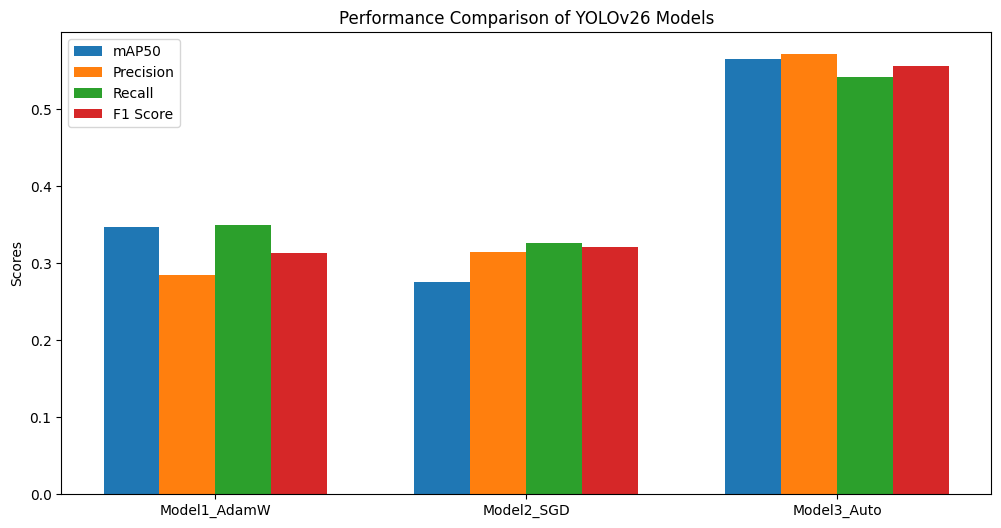

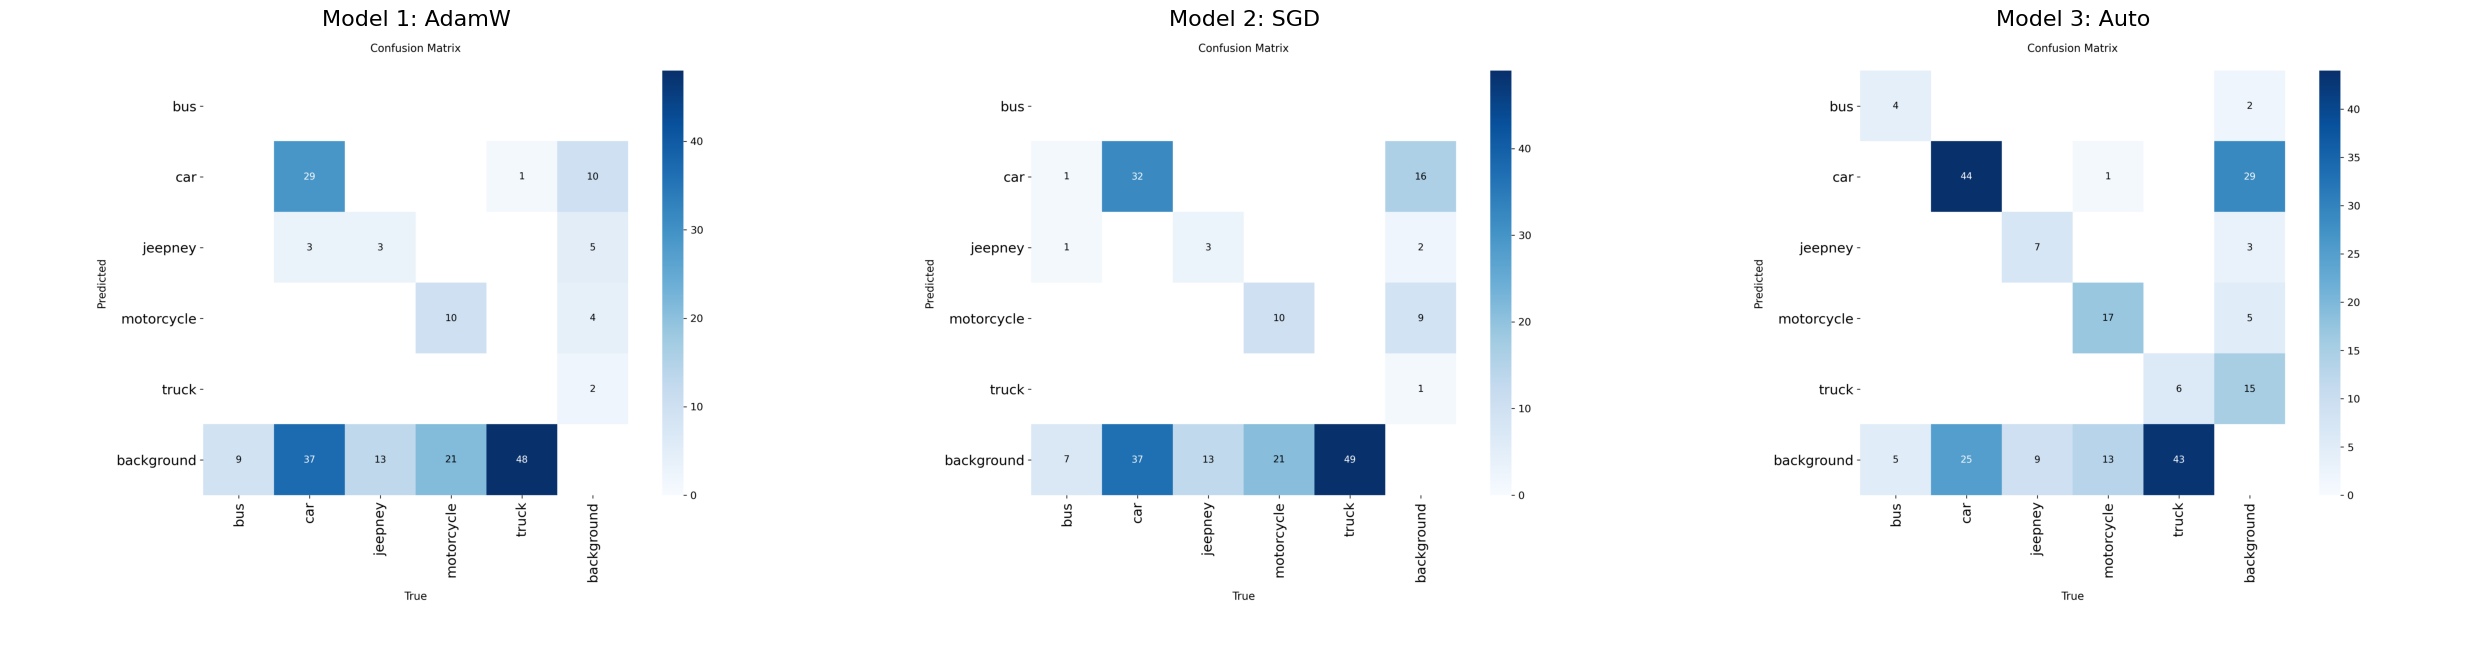

In [17]:
# Table 1
df_hp = pd.DataFrame(configs)
# The DataFrame constructor converts the list of dictionaries directly into a structured table format.
# This ensures the hyperparameter documentation is an exact reflection of the variables used during the training loop.

df_hp = df_hp[['name', 'optimizer', 'batch', 'epochs', 'lr0']]
# This line reorders the columns to prioritize the model name and the specific parameters being tested.
# Organizing the data this way improves the readability of the experimental setup for the final evaluation.

print("Table 1: Hyperparameter Settings")
display(df_hp)
# The display function renders the DataFrame as a formatted HTML table within the notebook interface.
# This satisfies the deliverable requirement for a clear summary of the three experimental configurations.

# Table 2
df_metrics = pd.DataFrame(results_list)
# We initialize a new DataFrame using the results_list to capture the final performance of each model.
# This creates a record of the precision, recall, and mAP50 scores for comparative analysis.

df_metrics = df_metrics[['Model', 'Optimizer', 'mAP50', 'Precision', 'Recall', 'F1 Score']]
# This reorders the metric columns to follow the standard reporting format for object detection tasks.
# It ensures that the most critical accuracy proxy, mAP50, is prominently displayed

print("\nTable 2: Validation Metrics")
display(df_metrics)
# Printing a descriptive header helps distinguish the results table from the configuration table.
# The display command provides the formatted output necessary for the screenshot deliverable in the PDF.

# Performacne Comparisons

x = np.arange(len(df_metrics['Model']))
width = 0.18
# We create an array of label locations on the x-axis to serve as anchors for the grouped bars.
# A width of 0.18 is selected to allow all four metrics to sit side-by-side without visual overlap.

fig, ax = plt.subplots(figsize=(12, 6))
# This initializes a wide figure canvas to accommodate the detailed performance data of all three models.
# Defining an explicit axes object allows for granular control over the labels, titles, and legends.

ax.bar(x - 1.5*width, df_metrics['mAP50'], width, label='mAP50')
ax.bar(x - 0.5*width, df_metrics['Precision'], width, label='Precision')
ax.bar(x + 0.5*width, df_metrics['Recall'], width, label='Recall')
ax.bar(x + 1.5*width, df_metrics['F1 Score'], width, label='F1 Score')
# These lines draw four separate bars for each model, using mathematical offsets to create the grouped effect.
# Each bar group represents a different dimension of the model's vehicle detection accuracy.

ax.set_ylabel('Scores')
ax.set_title('Performance Comparison of YOLOv26 Models')
ax.set_xticks(x)
ax.set_xticklabels(df_metrics['Model'])
ax.legend()
# We label the y-axis and set a descriptive title to provide context for the statistical comparison.
# The legend and tick labels are updated to ensure viewers can easily identify which model produced which result.

plt.savefig('performance_comparison.png')
plt.show()
# The savefig function exports the chart as a PNG file for inclusion in your local project directory.
# Calling show() renders the final visualization in the notebook to verify the data distribution.

# Confusion Matrice

matrix_paths = [
    '/content/runs/detect/Model1_AdamW/confusion_matrix.png',
    '/content/runs/detect/Model2_SGD/confusion_matrix.png',
    '/content/runs/detect/Model3_Auto/confusion_matrix.png'
]
# We define a list containing the file paths for the diagnostic matrices generated by each model configuration.
# This allows the code to iterate through the results and display them in a single layout.

fig, axes = plt.subplots(1, 3, figsize=(25, 10))
# This command creates a layout of one row and three columns to display the confusion matrice side-by-side.
# Using subplots is the correct way to show multiple images in a single cell without them overwriting each other.

model_names = ["Model 1: AdamW", "Model 2: SGD", "Model 3: Auto"]
# A list of descriptive titles is created to label each individual matrix for the final report.
# These labels help the observer correlate the visual background errors with the specific optimizer used.

for i, path in enumerate(matrix_paths):
    try:
        img = mpimg.imread(path)
        axes[i].imshow(img)
        axes[i].set_title(model_names[i], fontsize=16)
        axes[i].axis('off')
    except FileNotFoundError:
        axes[i].text(0.5, 0.5, f"Matrix not found at:\n{path}", ha='center')
        axes[i].axis('off')
# The loop reads each image file and renders it onto its assigned subplot within the larger figure.
# We include a try-except block to handle cases where a model might have failed to generate its matrix file.

plt.tight_layout()
plt.show()
# The tight_layout function automatically adjusts the spacing between subplots to prevent label clipping.
# This final show() command fulfills the deliverable requirement of displaying the matrices within the notebook.

### References

[1] Nitesh V. Chawla, Kevin W. Bowyer, Lawrence O. Hall, and W. Philip Kegelmeyer. 2002. SMOTE: Synthetic Minority Over-sampling Technique. J. Artif. Int. Res. 16, 1 (June 2002), 321–357.
<br>

[2] Mark Everingham, Luc Van Gool, Christopher K. I. Williams, John Winn, and Andrew Zisserman. 2010. The Pascal Visual Object Classes (VOC) Challenge. Int. J. Comput. Vis. 88, 2 (June 2010), 303–338. https://doi.org/10.1007/s11263-009-0275-4


[3] Tsung-Yi Lin, Michael Maire, Serge Belongie, James Hays, Pietro Perona, Deva Ramanan, Piotr Dollár, and C. Lawrence Zitnick. 2014. Microsoft COCO: Common Objects in Context. In Computer Vision – ECCV 2014, David Fleet, Tomas Pajdla, Bernt Schiele, and Tinne Tuytelaars (Eds.). Springer International Publishing, Cham, 740–755.<br>


[4] Ultralytics. (2024). YOLOv11/26 Documentation: Train Settings and Metrics. Available at: https://docs.ultralytics.com/usage/cfg/<br>


[5] Wang, C. Y., et al. (2024). YOLOv10/26: Real-Time End-to-End Object Detection (NMS-Free). arXiv:2405.14458.<br>


[6] Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python. Journal of Machi
ne Learning Research.<br>


[7] Pandas Development Team. (2024). pandas: Python Data Analysis Library. Available at: https://pandas.pydata.org/docs/